# 09h — Validazione MD di MOL00583–EGFR
**PEARL Pipeline 5 · dopo 09g · posa raffinata Vina da 09f**

MOL00583 è `TIER_1_PRIMARY_COMPUTATIONAL_LEAD`, selezionata in 09g. Rimane un **lead computazionale, non validato sperimentalmente**. Lo stato `NEAR_MISS_MANDATORY_ONLY` / `NEAR_MISS_RESCUE` viene preservato: la MD non lo trasforma in strict hit.

Il protocollo riprende i notebook locali `07a_EGFR_Dimer_OpenMM_MD_Setup.ipynb` e `07d_Selected_Peptide_MD_Comparison.ipynb`: OpenMM, ff14SB/TIP3P, 300 K, 1 bar, NaCl 0,15 M, 2 fs, minimizzazione, NVT, NPT e produzione. Qui il partner è una small molecule parametrizzata con OpenFF, non il peptide D. EGFR è **3NJP catena B, dominio extracellulare**, non il dominio chinasico.

Non sono inclusi risultati MD precalcolati. Eseguire dall'alto in un kernel con le dipendenze indicate nel README. La scoperta dei file non inventa né scarica input. `RUN_MD=False` lascia eseguire il preflight e ferma il notebook prima della preparazione/simulazione; impostare `True` per eseguire il test.

In [1]:
from pathlib import Path
import os, json, hashlib, csv, sys, platform, importlib.metadata as metadata
from datetime import datetime, timezone
import numpy as np
import pandas as pd

def require(ok, message):
    if not ok:
        raise RuntimeError(message)

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''):
            h.update(block)
    return h.hexdigest()

def dump(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding='utf-8')

CANDIDATE = 'MOL00583'
TIER = 'TIER_1_PRIMARY_COMPUTATIONAL_LEAD'
# PEARL_ROOT può essere impostato nell'ambiente o sostituito con Path('/percorso/reale').
PROJECT_ROOT = Path(os.environ['PEARL_ROOT']).expanduser() if os.environ.get('PEARL_ROOT') else None
# Override espliciti (None = nomi verificati degli output PEARL).
OVERRIDES = dict(receptor=None, ligand=None, ranking=None, qc09f=None, qc09g=None)
#RUN_MD = False
RUN_MD = True
FAST_TEST_MODE = True
SEED = 20260912  # cambiare per repliche indipendenti; ogni esecuzione crea un nuovo run
TEMPERATURE_K, PRESSURE_BAR, PH = 300.0, 1.0, 7.4
TIMESTEP_PS, FRICTION_PS = 0.002, 1.0
PADDING_NM, CUTOFF_NM, SALT_M = 1.0, 1.0, 0.15
NVT_PS = 10.0 if FAST_TEST_MODE else 100.0
NPT_PS = 10.0 if FAST_TEST_MODE else 100.0
PRODUCTION_PS = 50.0 if FAST_TEST_MODE else 1000.0  # 1 ns = confronto 07d; estendere per studio definitivo
FRAME_PS = 2.0
ANALYSIS_STRIDE = 1
DISCARD_FRACTION = 0.20  # solo produzione; dichiarato, non scelto a posteriori
PROTEIN_FF, WATER_FF = 'amber14/protein.ff14SB.xml', 'amber14/tip3p.xml'
LIGAND_FF = 'openff-2.2.1'
PLATFORM = 'CPU'  # modificare esplicitamente in CUDA/OpenCL se disponibili
PLATFORM_PROPERTIES = {}  # es. {'Precision': 'mixed'} su CUDA/OpenCL
CONTACT_NM, SITE_NM = 0.45, 0.60
RETENTION_DISTANCE_NM = 1.0  # distanza centro geometrico ligando–centro sito, soglia descrittiva
PERSISTENCE = 0.50
MINIMIZATION_ITERATIONS = 5000
RESTRAINT_K = 1000.0  # kJ mol^-1 nm^-2, solo minimizzazione/equilibrazione
# Altloc del recettore coerente con il comando 09f (--wanted_altloc B:172=A).
ALTLOC = 'A'
# Gaps/troncamenti non vengono ricostruiti automaticamente. Se compaiono,
# documentare una revisione strutturale prima di impostare questa nota.
STRUCTURE_REVIEW_NOTE = ''
OUTPUT_BASE = Path.cwd() / 'outputs' / 'pipeline_5_pharmacophore_09h_mol00583_md'

## 1. Scoperta e verifica degli input
Priorità: root esplicita → directory corrente se contiene gli output → percorso storico verificato. Più root valide causano un errore di ambiguità. Nessuna selezione per “file più recente”. La SDF preferita è quella **09f local-minimized**; un override deve conservare la stessa struttura e coordinate, oppure documentare la conversione prima di modificare il controllo. PDBQT non è una sorgente sufficiente di chimica per la parametrizzazione.

In [2]:
F_DIR = Path('outputs/pipeline_5_pharmacophore_09f_vina_refinement')
G_DIR = Path('outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection')
REL = {
    'receptor': F_DIR/'inputs/09f_receptor_chain_B.pdb',
    'ligand': F_DIR/'structures/MOL00583_09f_vina_local_minimized.sdf',
    'ranking': G_DIR/'tables/09g_integrated_lead_priority.csv',
    'qc09f': F_DIR/'tables/09f_QC.csv',
    'qc09g': G_DIR/'tables/09g_QC.csv',
}
if PROJECT_ROOT is None:
    candidates = list(dict.fromkeys(p.resolve() for p in
        [Path.cwd(), Path.home()/'Desktop/venv'] if (p/G_DIR).is_dir()))
    print('Root candidate:', [str(p) for p in candidates])
    require(len(candidates) == 1, 'Impostare PROJECT_ROOT/PEARL_ROOT: nessuna root o più root PEARL trovate.')
    PROJECT_ROOT = candidates[0]
PROJECT_ROOT = PROJECT_ROOT.resolve()
paths = {k: (Path(OVERRIDES[k]).expanduser().resolve() if OVERRIDES[k]
             else PROJECT_ROOT/v) for k,v in REL.items()}
missing = [f'{k}: {v}' for k,v in paths.items() if not v.is_file()]
require(not missing, 'Input 09f/09g obbligatori assenti:\n' + '\n'.join(missing))
require(paths['ligand'].suffix.lower() == '.sdf', 'Serve SDF chimicamente valida, non PDBQT/PDB.')
rank = pd.read_csv(paths['ranking'])
require({'candidate_id','priority_tier','pharmacophore_status','docking_track'} <= set(rank),
        'Schema 09g incompatibile: verificare le colonne nel CSV, senza inferire il tier.')
require(rank.candidate_id.is_unique, 'ID duplicati nel ranking 09g.')
selected = rank.loc[rank.candidate_id == CANDIDATE]
require(len(selected) == 1, 'MOL00583 assente/non univoca in 09g.')
lead = selected.iloc[0].to_dict()
require(lead['priority_tier'] == TIER and (rank.priority_tier == TIER).sum() == 1,
        'MOL00583 non è l’unico primary computational lead di 09g.')
require(lead['pharmacophore_status'] == 'NEAR_MISS_MANDATORY_ONLY' and
        lead['docking_track'] == 'NEAR_MISS_RESCUE', 'Provenienza farmacoforica inattesa: verificare 09g.')
for key in ['qc09f','qc09g']:
    q = pd.read_csv(paths[key], dtype=str)
    require('pass' in q and len(q)>0 and q['pass'].str.strip().str.lower().eq('true').all(),
            f'{key}: QC assente, vuoto o non superato.')
print('Input risolti:', *[f'{k}: {v}' for k,v in paths.items()], sep='\n')
display(selected)

Root candidate: ['/Users/robertobruzzese/Desktop/venv']
Input risolti:
receptor: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/inputs/09f_receptor_chain_B.pdb
ligand: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/structures/MOL00583_09f_vina_local_minimized.sdf
ranking: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection/tables/09g_integrated_lead_priority.csv
qc09f: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/tables/09f_QC.csv
qc09g: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09g_integrated_lead_selection/tables/09g_QC.csv


,09g_priority_rank,candidate_id,priority_tier,cross_method_support_label,pareto_nondominated,pharmacophore_status,mandatory_rmsd_A,pharmacophore_fit_rank,chemistry_class,chemistry_priority_score,...,vina_delta_local_optimization,vina_energetic_rank,diffdock_to_vina_local_RMSD_A,local_geometry_label,local_geometry_stability_rank,consensus_support_count_top2,consensus_support_fraction,median_axis_rank,worst_axis_rank,docking_track
0,1,MOL00583,TIER_1_PRIMARY_COMPUTATIONAL_LEAD,STRONG_CROSS_METHOD_SUPPORT,True,NEAR_MISS_MANDATORY_ONLY,1.340579,2,CHEM_PASS,3.781209,...,-4.698,2,0.586386,STABLE_LOCAL_GEOMETRY,4,4,0.666667,2.0,4,NEAR_MISS_RESCUE


In [12]:
import sys
print(sys.executable)
print(sys.version)

/Users/robertobruzzese/miniforge3/envs/pearl-ai/bin/python
3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]


In [10]:
%pip install rdkit mdtraj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 8.9 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 9.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mdtraj]
Note: you may need to restart the kernel to use updated packages.


## 2. Identità chimica e geometria iniziale
Si verifica la chimica contro la SDF di input 09f, conservando gli atomi pesanti della posa raffinata. Gli idrogeni vengono rigenerati nello stesso stato formale di protonazione della SDF: il pH configurato si applica alla proteina, **non effettua una previsione automatica dei microstati del ligando**. Niente embedding o minimizzazione RDKit degli atomi pesanti.

In [3]:
from rdkit import Chem

def read_single_sdf(path):
    molecules = list(Chem.SDMolSupplier(str(path), removeHs=False))
    require(len(molecules)==1 and molecules[0] is not None, f'SDF non valida/univoca: {path}')
    m = molecules[0]
    require(m.GetNumConformers()==1 and m.GetConformer().Is3D(), 'SDF senza posa 3D.')
    require(len(Chem.GetMolFrags(m))==1, 'Ligando multiframmento: definire il microstato corretto.')
    return m

def identity(m):
    return Chem.MolToSmiles(Chem.RemoveHs(m), isomericSmiles=True)

pose = read_single_sdf(paths['ligand'])
chem_source = PROJECT_ROOT/F_DIR/'inputs/MOL00583_diffdock_pose_H.sdf'
require(chem_source.is_file(), f'Input chimico 09f assente: {chem_source}')
require(identity(pose)==identity(read_single_sdf(chem_source)), 'Chimica della posa diversa dall’input 09f.')
canonical_pose = PROJECT_ROOT/REL['ligand']
require(canonical_pose.is_file(), f'Posa canonica 09f assente: {canonical_pose}')
original = Chem.RemoveHs(read_single_sdf(canonical_pose))
heavy = Chem.RemoveHs(pose)
require(identity(original)==identity(heavy), 'Override diverso da MOL00583 raffinata in 09f.')
match = heavy.GetSubstructMatch(original, useChirality=True)
require(len(match)==original.GetNumAtoms(), 'Mappatura atomi 09f fallita.')
require(np.max(np.linalg.norm(heavy.GetConformer().GetPositions()[list(match)] -
                             original.GetConformer().GetPositions(), axis=1)) < 0.01,
        'Coordinate override non equivalenti alla posa 09f (<0.01 Å richiesto).')
lig_rd = Chem.AddHs(heavy, addCoords=True)
xyz_A = lig_rd.GetConformer().GetPositions()
require(np.isfinite(xyz_A).all(), 'Coordinate ligando non finite.')
formal_charge = Chem.GetFormalCharge(lig_rd)
print('SMILES verificata:', identity(lig_rd), '\nCarica formale:', formal_charge)
# Controllo preliminare nel sistema di coordinate originale, altloc esplicita.
lines = paths['receptor'].read_text().splitlines()
records = [s for s in lines if s.startswith(('ATOM  ','HETATM'))]
require(records and all(s[21]=='B' for s in records), 'Il recettore deve contenere solo la catena EGFR B.')
require(not any(s.startswith('HETATM') for s in records),
        'Eterogeni presenti: decidere esplicitamente trattamento di glicani/cofattori/acque.')
records = [s for s in records if s[16] in (' ', ALTLOC)]
rec_A = np.array([[float(s[30:38]),float(s[38:46]),float(s[46:54])]
                  for s in records if s[76:78].strip() != 'H'])
lig_A = heavy.GetConformer().GetPositions()
dmin = np.sqrt(((rec_A[:,None,:]-lig_A[None,:,:])**2).sum(2)).min()
require(np.isfinite(rec_A).all() and 1.0 < dmin < 6.0,
        f'Complesso non plausibile: minima distanza pesante {dmin:.3f} Å (clash o frame errato).')
print('Distanza minima recettore–ligando:', round(dmin,3), 'Å')

SMILES verificata: COc1ccc(NC(C)=O)cc1NC(=O)c1cnc(Nc2ccc(C)c(C)c2)nc1 
Carica formale: 0
Distanza minima recettore–ligando: 2.979 Å


In [6]:
import sys
import importlib.util

print("Python del kernel:", sys.executable)
print("OpenMM presente:", importlib.util.find_spec("openmm") is not None)

Python del kernel: /Users/robertobruzzese/miniforge3/envs/pearl-ai/bin/python
OpenMM presente: False


## 3. Dipendenze e cartella di esecuzione
Il preflight precedente funziona senza OpenMM. Da qui servono OpenMM, PDBFixer, OpenFF Toolkit con AmberTools, openmmforcefields e MDTraj. Nessuna installazione automatica nel kernel. Una cartella univoca impedisce sovrascritture accidentali; in caso di interruzione rimangono log, checkpoint e stato del run.

In [4]:
require(RUN_MD, 'Preflight completato. Impostare RUN_MD=True e rieseguire dall’inizio per preparazione e MD.')
try:
    import openmm as mm
    from openmm import app, unit
    import mdtraj as mt
    from pdbfixer import PDBFixer
    from openff.toolkit import Molecule
    from openff.toolkit.utils import AmberToolsToolkitWrapper, RDKitToolkitWrapper, ToolkitRegistry
    from openff.units import unit as offunit
    from openmmforcefields.generators import SMIRNOFFTemplateGenerator
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise RuntimeError('Dipendenze MD mancanti: usare l’ambiente descritto nel README.') from exc

RUN = OUTPUT_BASE / (datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ') + f'_seed{SEED}')
RUN.mkdir(parents=True, exist_ok=False)
for name in ['inputs','structures','states','trajectories','tables','plots']:
    (RUN/name).mkdir()
input_manifest = {k: {'path':str(p), 'sha256':sha256(p)} for k,p in
                  dict(paths, chemistry_source=chem_source, canonical_pose=canonical_pose).items()}
versions = {}
for name in ['openmm','pdbfixer','openff-toolkit','openff-forcefields','openmmforcefields','mdtraj','rdkit','numpy','pandas']:
    try: versions[name] = metadata.version(name)
    except metadata.PackageNotFoundError: versions[name] = 'unknown'
config = {k:v for k,v in list(globals().items()) if k.isupper() and isinstance(v,(str,int,float,bool,dict,Path))}
provenance = dict(candidate=CANDIDATE, tier=TIER, experimentally_validated=False,
                  lead09g=lead, input_manifest=input_manifest, versions=versions,
                  python=sys.version, host_platform=platform.platform(), config=config,
                  created_utc=datetime.now(timezone.utc).isoformat(), status='preparing')
dump(RUN/'provenance.json', provenance)
print('Run:', RUN)

Run: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09h_mol00583_md/20260912T161426_861450Z_seed20260912


In [6]:
import os
import sys
import shutil
from pathlib import Path

kernel_bin = str(Path(sys.executable).parent)
os.environ["PATH"] = kernel_bin + os.pathsep + os.environ.get("PATH", "")

from openff.toolkit.utils import AmberToolsToolkitWrapper

print("antechamber:", shutil.which("antechamber"))
print("sqm:", shutil.which("sqm"))
print("AmberTools disponibile:", AmberToolsToolkitWrapper.is_available())

antechamber: /Users/robertobruzzese/miniforge3/envs/pearl-09h/bin/antechamber
sqm: /Users/robertobruzzese/miniforge3/envs/pearl-09h/bin/sqm
AmberTools disponibile: True


## 4. Preparazione recettore e parametri del ligando
PDBFixer segnala residui/atomi mancanti. Si ricostruiscono solo atomi mancanti di residui esistenti; loop mancanti, termini e discontinuità richiedono revisione. Un PDB senza SEQRES non permette di provare la completezza della sequenza. Il modello eredita le omissioni del recettore di docking (es. glicani). Si conserva una mappa degli atomi e dei residui, inclusa la numerazione originale.

OpenFF Sage usa cariche AM1-BCC via AmberTools; nessun fallback a cariche nulle/Gasteiger. Stereochimica indefinita o mancata copertura parametrica causano un errore. I parametri serializzati e la chimica con cariche sono conservati per 09i.

In [7]:
import random
random.seed(SEED)
np.random.seed(SEED)
clean = RUN/'inputs/receptor_altloc_selected.pdb'
# Preserva TER/SEQRES/SSBOND/CONECT; rimuove solo conformeri alternativi non scelti.
clean_lines = []
for s in lines:
    if s.startswith(('ATOM  ','HETATM')):
        if s[16] not in (' ', ALTLOC): continue
        s = s[:16]+' '+s[17:]
    clean_lines.append(s)
clean.write_text('\n'.join(clean_lines)+'\n')
fixer = PDBFixer(filename=str(clean))
fixer.findMissingResidues()
fixer.findNonstandardResidues()
require(not fixer.nonstandardResidues, 'Residui non standard: servono parametri/modello espliciti.')
fixer.findMissingAtoms()
gaps = []
for chain in fixer.topology.chains():
    rr = list(chain.residues())
    for a,b in zip(rr,rr[1:]):
        if int(b.id)-int(a.id) != 1:
            gaps.append([chain.id,a.id,b.id])
prep_qc = dict(missing_residues={str(k):v for k,v in fixer.missingResidues.items()},
               numbering_gaps=gaps, missing_atoms={str(r):[a.name for a in aa] for r,aa in fixer.missingAtoms.items()},
               missing_terminals={str(r):v for r,v in fixer.missingTerminals.items()},
               review_note=STRUCTURE_REVIEW_NOTE, altloc=ALTLOC)
dump(RUN/'tables/preparation_qc.json', prep_qc)
require(not (gaps or fixer.missingResidues) or bool(STRUCTURE_REVIEW_NOTE.strip()),
        'Discontinuità rilevate: vedere preparation_qc.json; preparare il modello o documentare STRUCTURE_REVIEW_NOTE.')
fixer.missingResidues = {}
fixer.addMissingAtoms(seed=SEED)
ff = app.ForceField(PROTEIN_FF, WATER_FF)
receptor = app.Modeller(fixer.topology, fixer.positions)
variants = receptor.addHydrogens(ff, pH=PH)
prep_qc['hydrogen_variants'] = variants
# Controlla bond C–N: evita legami artificiali attraverso segmenti mancanti.
xyz = receptor.positions.value_in_unit(unit.nanometer)
for a,b in receptor.topology.bonds():
    if a.residue != b.residue and {a.name,b.name} == {'C','N'}:
        require(np.linalg.norm(np.array(xyz[a.index])-np.array(xyz[b.index])) < 0.20,
                'Legame peptidico >2 Å: correggere la struttura prima della MD.')
dump(RUN/'tables/preparation_qc.json', prep_qc)
registry = ToolkitRegistry([RDKitToolkitWrapper(), AmberToolsToolkitWrapper()])
lig = Molecule.from_rdkit(lig_rd, allow_undefined_stereo=False, hydrogens_are_explicit=True)
lig.name = CANDIDATE
lig.assign_partial_charges('am1bcc', toolkit_registry=registry)
charges = lig.partial_charges.m_as(offunit.elementary_charge)
require(np.isfinite(charges).all() and abs(charges.sum()-formal_charge)<1e-4, 'Cariche AM1-BCC non valide.')
(RUN/'inputs/ligand_openff.json').write_text(lig.to_json())
writer = Chem.SDWriter(str(RUN/'inputs/ligand_pose_H.sdf')); writer.write(lig_rd); writer.close()
generator = SMIRNOFFTemplateGenerator(molecules=[lig], forcefield=LIGAND_FF,
                                      cache=str(RUN/'states/ligand_template_cache.json'))
ff.registerTemplateGenerator(generator.generator)
ligtop = lig.to_topology().to_openmm()
for c in ligtop.chains(): c.id = 'L'
for r in ligtop.residues(): r.name = 'LIG'; r.id = '1'
for i,a in enumerate(ligtop.atoms()): a.name = f'{a.element.symbol}{i+1}'
model = app.Modeller(receptor.topology, receptor.positions)
n_rec = model.topology.getNumAtoms()
model.add(ligtop, xyz_A/10 * unit.nanometer)
n_solute = model.topology.getNumAtoms()
rec_idx = np.arange(n_rec); lig_idx = np.arange(n_rec,n_solute)
require(len(lig_idx)==lig.n_atoms, 'Ordine/dimensione ligando non coerenti.')
# Parametrizzazione a secco: fallisce qui, prima di creare migliaia di acque.
dry_system = ff.createSystem(model.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds)
require(dry_system.getNumParticles()==n_solute, 'Numero particelle inatteso.')
def write_pdb(path, topology, positions):
    with Path(path).open('w') as f: app.PDBFile.writeFile(topology, positions, f, keepIds=True)
write_pdb(RUN/'structures/complex_prepared.pdb', model.topology, model.positions)
solute_top = mt.Topology.from_openmm(model.topology)
reference_xyz = np.array(model.positions.value_in_unit(unit.nanometer))
reference = mt.Trajectory(reference_xyz[None,:,:], solute_top)
reference.save_pdb(str(RUN/'structures/solute_reference_09f.pdb'))
# JSON conserva i bond (PDB da solo può perdere quelli del ligando).
bonds = [[a.index,b.index] for a,b in model.topology.bonds()]
atoms = [dict(index=a.index, name=a.name, element=a.element.symbol,
              residue_index=a.residue.index, residue_name=a.residue.name,
              residue_id=a.residue.id, insertion_code=a.residue.insertionCode,
              chain=a.residue.chain.id, component='EGFR' if a.index<n_rec else CANDIDATE)
         for a in model.topology.atoms()]
pd.DataFrame(atoms).to_csv(RUN/'tables/solute_atom_map.csv', index=False)
dump(RUN/'tables/solute_bonds.json', bonds)

/Users/robertobruzzese/miniforge3/envs/pearl-09h/lib/python3.11/site-packages/openff/interchange/components/interchange.py:1119: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, functools._lru_cache_wrapper) and obj.__module__.startswith("openff.interchange"):
/Users/robertobruzzese/miniforge3/envs/pearl-09h/lib/python3.11/site-packages/openff/interchange/smirnoff/_create.py:151: PresetChargesAndVirtualSitesWarning: Preset charges were provided (via `charge_from_molecules`) alongside a force field that includes virtual site parameters. Note that virtual sites will be applied charges from the force field and cannot be given preset charges. Virtual sites may also affect the charges of their orientation atoms, even if those atoms are given preset charges.
  warnings.warn(


## 5. Solvatazione, ioni e sistema periodico
TIP3P, neutralizzazione e NaCl aggiuntivo 0,15 M. I controioni di neutralizzazione non sono conteggiati come coppie di sale aggiunte. PME, cutoff 1 nm, vincoli sui legami con H, nessuna modifica delle masse. Il sistema fisico senza restrizioni è salvato separatamente dal sistema di equilibrazione.

In [8]:
model.addSolvent(ff, model='tip3p', padding=PADDING_NM*unit.nanometer,
                 ionicStrength=SALT_M*unit.molar, positiveIon='Na+', negativeIon='Cl-', neutralize=True)
system = ff.createSystem(model.topology, nonbondedMethod=app.PME,
                         nonbondedCutoff=CUTOFF_NM*unit.nanometer,
                         constraints=app.HBonds, rigidWater=True)
require(system.getNumParticles()==model.topology.getNumAtoms(), 'Particelle/topologia non coincidono.')
nbforce = next(f for f in system.getForces() if isinstance(f, mm.NonbondedForce))
net_charge = sum(nbforce.getParticleParameters(i)[0].value_in_unit(unit.elementary_charge)
                 for i in range(system.getNumParticles()))
require(abs(net_charge)<1e-3, f'Sistema non neutralizzato: {net_charge}')
counts = pd.Series([r.name for r in model.topology.residues()]).value_counts().to_dict()
require(counts.get('HOH',0)>0, 'Nessuna acqua aggiunta.')
dump(RUN/'tables/solvation.json', dict(residue_counts=counts, net_charge_e=net_charge))
write_pdb(RUN/'structures/solvated.pdb', model.topology, model.positions)
(RUN/'states/physical_system.xml').write_text(mm.XmlSerializer.serialize(system))
# Restrizioni periodiche sugli atomi pesanti di EGFR + ligando, riferite alla posa iniziale.
restraint = mm.CustomExternalForce('0.5*k*periodicdistance(x,y,z,x0,y0,z0)^2')
restraint.addGlobalParameter('k', RESTRAINT_K)
for name in ['x0','y0','z0']: restraint.addPerParticleParameter(name)
for a in list(model.topology.atoms())[:n_solute]:
    if a.element.symbol != 'H': restraint.addParticle(a.index, reference_xyz[a.index].tolist())
restraint_index = system.addForce(restraint)
barostat = mm.MonteCarloBarostat(PRESSURE_BAR*unit.bar, TEMPERATURE_K*unit.kelvin, 25)
barostat.setRandomNumberSeed(SEED+1)
barostat.setFrequency(0)  # NVT vero: barostato disattivato
system.addForce(barostat)
platform_mm = mm.Platform.getPlatformByName(PLATFORM)
def integrator(seed):
    it = mm.LangevinMiddleIntegrator(TEMPERATURE_K*unit.kelvin,
                                    FRICTION_PS/unit.picosecond,TIMESTEP_PS*unit.picosecond)
    it.setRandomNumberSeed(seed); it.setConstraintTolerance(1e-6)
    return it
sim = app.Simulation(model.topology,system,integrator(SEED),platform_mm,PLATFORM_PROPERTIES)
sim.context.setPositions(model.positions)
provenance['openmm_platform'] = sim.context.getPlatform().getName()
provenance['status'] = 'prepared'
dump(RUN/'provenance.json',provenance)

## 6. Minimizzazione e NVT/NPT
Minimizzazione con restrizioni; NVT alla temperatura obiettivo; NPT con rilascio in quattro gradini fino a k=0. Le durate brevi sono valori iniziali, non garanzie di equilibrio. Ispezionare temperatura, densità, energia e dipendenza temporale; prolungare NPT quando necessario.

In [9]:
def steps(ps):
    value = ps/TIMESTEP_PS
    require(value>0 and abs(value-round(value))<1e-6, f'Durata {ps} ps non multipla del timestep.')
    return int(round(value))
interval = steps(FRAME_PS)
require(steps(PRODUCTION_PS)%interval==0, 'La produzione deve essere multipla di FRAME_PS.')
require(steps(NPT_PS)%4==0, 'NPT deve essere divisibile in quattro stadi.')

def snapshot(sim, label):
    state = sim.context.getState(getPositions=True,getVelocities=True,getEnergy=True,getParameters=True)
    e = state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
    require(np.isfinite(e) and np.isfinite(state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)).all(),
            f'{label}: energia/coordinate non finite.')
    (RUN/f'states/{label}.xml').write_text(mm.XmlSerializer.serialize(state))
    sim.saveCheckpoint(str(RUN/f'states/{label}.chk'))
    return state

def log_reporter(name):
    return app.StateDataReporter(str(RUN/f'tables/{name}.csv'), interval,
        step=True,time=True,potentialEnergy=True,kineticEnergy=True,totalEnergy=True,
        temperature=True,volume=True,density=True,speed=True,separator=',')

initial_e = sim.context.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
sim.minimizeEnergy(tolerance=10*unit.kilojoule_per_mole/unit.nanometer,
                   maxIterations=MINIMIZATION_ITERATIONS)
min_state = snapshot(sim,'minimized')
min_e = min_state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
require(min_e<=initial_e+1e-3, 'L’energia non è diminuita durante la minimizzazione.')
dump(RUN/'tables/minimization.json',dict(initial_kJ_mol=initial_e,final_kJ_mol=min_e,
     note='Energia con restrizioni; riduzione non dimostra convergenza del gradiente.'))
sim.context.setVelocitiesToTemperature(TEMPERATURE_K*unit.kelvin,SEED)
sim.reporters = [log_reporter('nvt')]
sim.step(steps(NVT_PS)); snapshot(sim,'nvt')
sim.reporters = []
barostat.setFrequency(25)
sim.context.reinitialize(preserveState=True)
sim.reporters = [log_reporter('npt')]
for k in [RESTRAINT_K, RESTRAINT_K/10, RESTRAINT_K/100, 0.0]:
    sim.context.setParameter('k',k)
    sim.step(steps(NPT_PS)//4)
equil = snapshot(sim,'equilibrated')
sim.reporters = []
(RUN/'states/equilibration_system.xml').write_text(mm.XmlSerializer.serialize(system))

69710313

## 7. Produzione NPT senza restrizioni
La forza di restrizione viene **rimossa** dal sistema. Il tempo e il contatore degli step sono azzerati all'inizio della produzione. DCD completo con solvente e box + DCD del soluto, checkpoint periodico e stato finale. Le coordinate DCD sono non avvolte (`enforcePeriodicBox=False`); nessun reimaging del ligando sul sito che possa mascherare un allontanamento.

In [10]:
system.removeForce(restraint_index)
require(not any(isinstance(f,mm.CustomExternalForce) for f in system.getForces()), 'Restrizioni residue.')
prod_it = integrator(SEED+2)
prod = app.Simulation(model.topology,system,prod_it,platform_mm,PLATFORM_PROPERTIES)
prod.context.setPeriodicBoxVectors(*equil.getPeriodicBoxVectors())
prod.context.setPositions(equil.getPositions()); prod.context.setVelocities(equil.getVelocities())
prod.context.setTime(0*unit.picosecond); prod.currentStep = 0
(RUN/'states/production_system.xml').write_text(mm.XmlSerializer.serialize(system))
(RUN/'states/production_integrator.xml').write_text(mm.XmlSerializer.serialize(prod_it))
start = prod.context.getState(getPositions=True)
write_pdb(RUN/'structures/production_start.pdb',model.topology,start.getPositions())
prod.reporters = [
    app.DCDReporter(str(RUN/'trajectories/production_full.dcd'), interval, enforcePeriodicBox=False),
    app.DCDReporter(str(RUN/'trajectories/production_solute.dcd'), interval,
                    atomSubset=list(range(n_solute)), enforcePeriodicBox=False),
    log_reporter('production'),
    app.CheckpointReporter(str(RUN/'states/production_latest.chk'), interval*10)
]
provenance['status']='production_running'; dump(RUN/'provenance.json',provenance)
try:
    prod.step(steps(PRODUCTION_PS))
    final_state = snapshot(prod,'production_final')
    write_pdb(RUN/'structures/production_final.pdb', model.topology, final_state.getPositions())
except Exception as exc:
    provenance.update(status='production_failed',error=repr(exc))
    dump(RUN/'provenance.json',provenance)
    raise
finally:
    prod.reporters = []  # chiude/flush dei reporter prima di rileggere i file
provenance['status']='production_completed'; dump(RUN/'provenance.json',provenance)

## 8. Traiettoria, PBC e RMSD
Il riferimento è il complesso preparato dalla posa 09f, prima della minimizzazione. Si allinea ogni frame sulle Cα di EGFR. L'RMSD del ligando è calcolato **dopo il solo fit della proteina**, senza fit indipendente del ligando (che nasconderebbe traslazioni/rotazioni). La corrispondenza atomica è fissa, senza correzione di simmetria.

Le distanze di contatto usano il minimo d'immagine periodico sui frame originali; RMSD e distanza dal sito usano coordinate continue e allineate, senza riavvicinare artificialmente il ligando. Il QC controlla la continuità dei legami e segnala grandi salti fra frame. Esportare coordinate allineate senza box evita di associare un box non ruotato a coordinate ruotate.

In [11]:
traj = mt.load_dcd(str(RUN/'trajectories/production_solute.dcd'), top=solute_top)
require(traj.n_atoms==n_solute and traj.n_frames==steps(PRODUCTION_PS)//interval,
        'Traiettoria incompleta o topologia incompatibile.')
require(np.isfinite(traj.xyz).all() and traj.unitcell_vectors is not None, 'Coordinate/box assenti o non finiti.')
require(np.isfinite(traj.unitcell_vectors).all(), 'Box non finiti.')
traj.time = (np.arange(traj.n_frames)+1)*FRAME_PS  # ps dalla produzione; DCD non ha t=0
sample = traj[::ANALYSIS_STRIDE]
require(0<=DISCARD_FRACTION<1 and ANALYSIS_STRIDE>=1, 'Configurazione analisi non valida.')
cut = int(sample.n_frames*DISCARD_FRACTION)
analysis = sample[cut:]
require(analysis.n_frames>=5, 'Meno di 5 frame per analisi: estendere la produzione.')
ca = np.array([a.index for a in solute_top.atoms if a.index<n_rec and a.name=='CA'])
ligheavy = np.array([a.index for a in solute_top.atoms if a.index>=n_rec and a.element.symbol!='H'])
recheavy = np.array([a.index for a in solute_top.atoms if a.index<n_rec and a.element.symbol!='H'])
require(len(ca)>=3 and len(ligheavy)>0, 'Selezioni atomiche vuote/non valide.')
bond_lengths = mt.compute_distances(sample,np.array(bonds),periodic=False)
require(np.isfinite(bond_lengths).all() and bond_lengths.max()<0.30,
        'Legami spezzati nelle coordinate non avvolte: correggere PBC prima dell’analisi.')
aligned_all = sample[:]
aligned_all.superpose(reference, atom_indices=ca)
aligned_all.unitcell_vectors = None
aligned = aligned_all[cut:]
aligned_all.save_dcd(str(RUN/'trajectories/solute_aligned_no_box.dcd'))
aligned_all[0].save_pdb(str(RUN/'structures/solute_aligned_topology.pdb'))
def fixed_rmsd(xyz,ref,indices):
    return np.sqrt(np.mean(np.sum((xyz[:,indices]-ref[None,indices])**2,axis=2),axis=1))*10
protein_rmsd = fixed_rmsd(aligned_all.xyz,reference.xyz[0],ca)
ligand_rmsd = fixed_rmsd(aligned_all.xyz,reference.xyz[0],ligheavy)
# Sito definito una sola volta dalla posa 09f (residui entro 6 Å).
initial_dist = np.linalg.norm(reference.xyz[0][recheavy][:,None,:]-reference.xyz[0][ligheavy][None,:,:],axis=2)
site_res = sorted({solute_top.atom(int(i)).residue.index for i in recheavy[initial_dist.min(1)<SITE_NM]})
require(site_res, 'Nessun residuo nel sito iniziale.')
site_atoms = np.array([i for i in recheavy if solute_top.atom(int(i)).residue.index in site_res])
center_distance = np.linalg.norm(aligned_all.xyz[:,ligheavy].mean(1)-aligned_all.xyz[:,site_atoms].mean(1),axis=1)
metrics = pd.DataFrame(dict(time_ps=sample.time,protein_CA_RMSD_A=protein_rmsd,
         ligand_heavy_RMSD_receptor_fit_A=ligand_rmsd,ligand_site_center_distance_A=center_distance*10,
         included_in_summary=np.arange(sample.n_frames)>=cut))

## 9. Contatti persistenti, ritenzione e RMSF
Contatto residuo–ligando: almeno una coppia di atomi pesanti a ≤4,5 Å. Si analizzano tutti i residui EGFR, mantenendo la distinzione dal sito iniziale. Occupancy = frazione dei frame post-scarto; non equivale a probabilità di binding. La ritenzione descrittiva richiede contatto con il sito iniziale e centro ligando entro la soglia configurata. Esportati anche contatti nativi e loro frazione mantenuta.

RMSF: Cα rispetto alla propria posizione media dopo fit globale di EGFR, limitata ai residui del sito. Un aumento può includere moti del dominio, non solo flessibilità locale.

In [12]:
residues = [r for r in solute_top.residues if any(a.index<n_rec for a in r.atoms)]
contact_series, rows = [], []
for r in residues:
    ri = [a.index for a in r.atoms if a.element.symbol!='H']
    pairs = np.array([(i,j) for i in ri for j in ligheavy],dtype=int)
    distance = mt.compute_distances(sample,pairs,periodic=True).min(1)
    present = distance<=CONTACT_NM
    native = bool(mt.compute_distances(reference,pairs,periodic=False).min()<=CONTACT_NM)
    contact_series.append(present)
    orig = atoms[ri[0]]
    rows.append(dict(residue_index=r.index,chain=orig['chain'],residue_id=orig['residue_id'],
        insertion_code=orig['insertion_code'],residue_name=r.name,
        initial_site=r.index in site_res,native_contact=native,
        occupancy=float(present[cut:].mean()),persistent=bool(present[cut:].mean()>=PERSISTENCE)))
contact_matrix = np.array(contact_series).T
contacts = pd.DataFrame(rows)
site_cols = contacts.initial_site.to_numpy()
native_cols = contacts.native_contact.to_numpy()
metrics['site_contact_count'] = contact_matrix[:,site_cols].sum(1)
metrics['all_EGFR_contact_count'] = contact_matrix.sum(1)
metrics['native_contact_fraction'] = contact_matrix[:,native_cols].mean(1) if native_cols.any() else np.nan
metrics['retained_descriptive'] = (metrics.site_contact_count>0) & (center_distance<=RETENTION_DISTANCE_NM)
metrics.to_csv(RUN/'tables/trajectory_metrics.csv',index=False)
contacts.to_csv(RUN/'tables/contact_persistence.csv',index=False)
np.savez_compressed(RUN/'tables/residue_contacts.npz',contacts=contact_matrix,time_ps=sample.time,
                    residue_indices=contacts.residue_index.to_numpy())
site_ca = np.array([i for i in ca if solute_top.atom(int(i)).residue.index in site_res])
rmsf = np.sqrt(np.mean(np.sum((aligned.xyz[:,site_ca]-aligned.xyz[:,site_ca].mean(0))**2,axis=2),axis=0))*10
rmsf_df = pd.DataFrame([dict(atom_index=int(i),chain=atoms[i]['chain'],residue_id=atoms[i]['residue_id'],
                residue_name=atoms[i]['residue_name'],RMSF_A=float(v)) for i,v in zip(site_ca,rmsf)])
rmsf_df.to_csv(RUN/'tables/binding_site_CA_RMSF.csv',index=False)
# Differenze fra metà iniziale/finale come diagnostica descrittiva (non test di convergenza).
summary_metrics = metrics.loc[metrics.included_in_summary]
mid = len(summary_metrics)//2
summary_metrics.iloc[:mid].mean(numeric_only=True).to_csv(RUN/'tables/first_half_means.csv')
summary_metrics.iloc[mid:].mean(numeric_only=True).to_csv(RUN/'tables/second_half_means.csv')

## 10. Legami a idrogeno geometrici (opzionali)
Baker–Hubbard: H···accettore <2,5 Å e angolo D–H···A >120°. Si mantengono solo interazioni EGFR–MOL00583, non acque o interazioni interne. Il criterio N/O di MDTraj non è una classificazione chimica esaustiva degli accettori; interpretare come candidati geometrici e verificare protonazione/tautomeria. Errori sono registrati come “non disponibile”, distinti da zero legami.

In [13]:
hb_status = {'status':'not_run'}
try:
    triples = mt.baker_hubbard(analysis,freq=0.0,exclude_water=True,periodic=True)
    triples = np.array([t for t in triples if (t[0]<n_rec)!=(t[2]<n_rec)],dtype=int).reshape(-1,3)
    hb_rows=[]
    for d,h,a in triples:
        distances = mt.compute_distances(analysis,np.array([[h,a]]),periodic=True)[:,0]
        angles = mt.compute_angles(analysis,np.array([[d,h,a]]),periodic=True)[:,0]
        occupancy = float(((distances<0.25)&(angles>np.deg2rad(120))).mean())
        hb_rows.append(dict(donor=int(d),hydrogen=int(h),acceptor=int(a),
                            donor_label=str(solute_top.atom(d)),acceptor_label=str(solute_top.atom(a)),
                            occupancy=occupancy))
    pd.DataFrame(hb_rows,columns=['donor','hydrogen','acceptor','donor_label','acceptor_label','occupancy']).to_csv(
        RUN/'tables/hydrogen_bonds_geometric.csv',index=False)
    hb_status = {'status':'computed','n_triplets':len(hb_rows),'method':'Baker-Hubbard geometric N/O'}
except Exception as exc:
    hb_status = {'status':'unavailable','reason':repr(exc)}
dump(RUN/'tables/hydrogen_bond_status.json',hb_status)
print(hb_status)

{'status': 'computed', 'n_triplets': 3, 'method': 'Baker-Hubbard geometric N/O'}


## 11. QC, grafici e pacchetto per 09i
Il QC tecnico non promuove né declassa automaticamente il lead. Un ligando che si allontana resta un risultato da riportare, non un errore da occultare. Le soglie temperatura/densità sono diagnostiche configurate nel codice; l'assenza di dissociazione in 50 ps o 1 ns non prova affinità o convergenza. Per conclusioni robuste servono durate più lunghe, repliche indipendenti e controlli pertinenti.

09i deve usare `physical_system.xml` + topologia e traiettoria complete/non allineate per preservare ordine atomico, box e parametri. `production_system.xml` include il barostato. L'energia potenziale del sistema non è ΔG di binding; eventuali MM-GBSA/MM-PBSA richiedono scelte separate di solvente implicito e topologie coerenti.

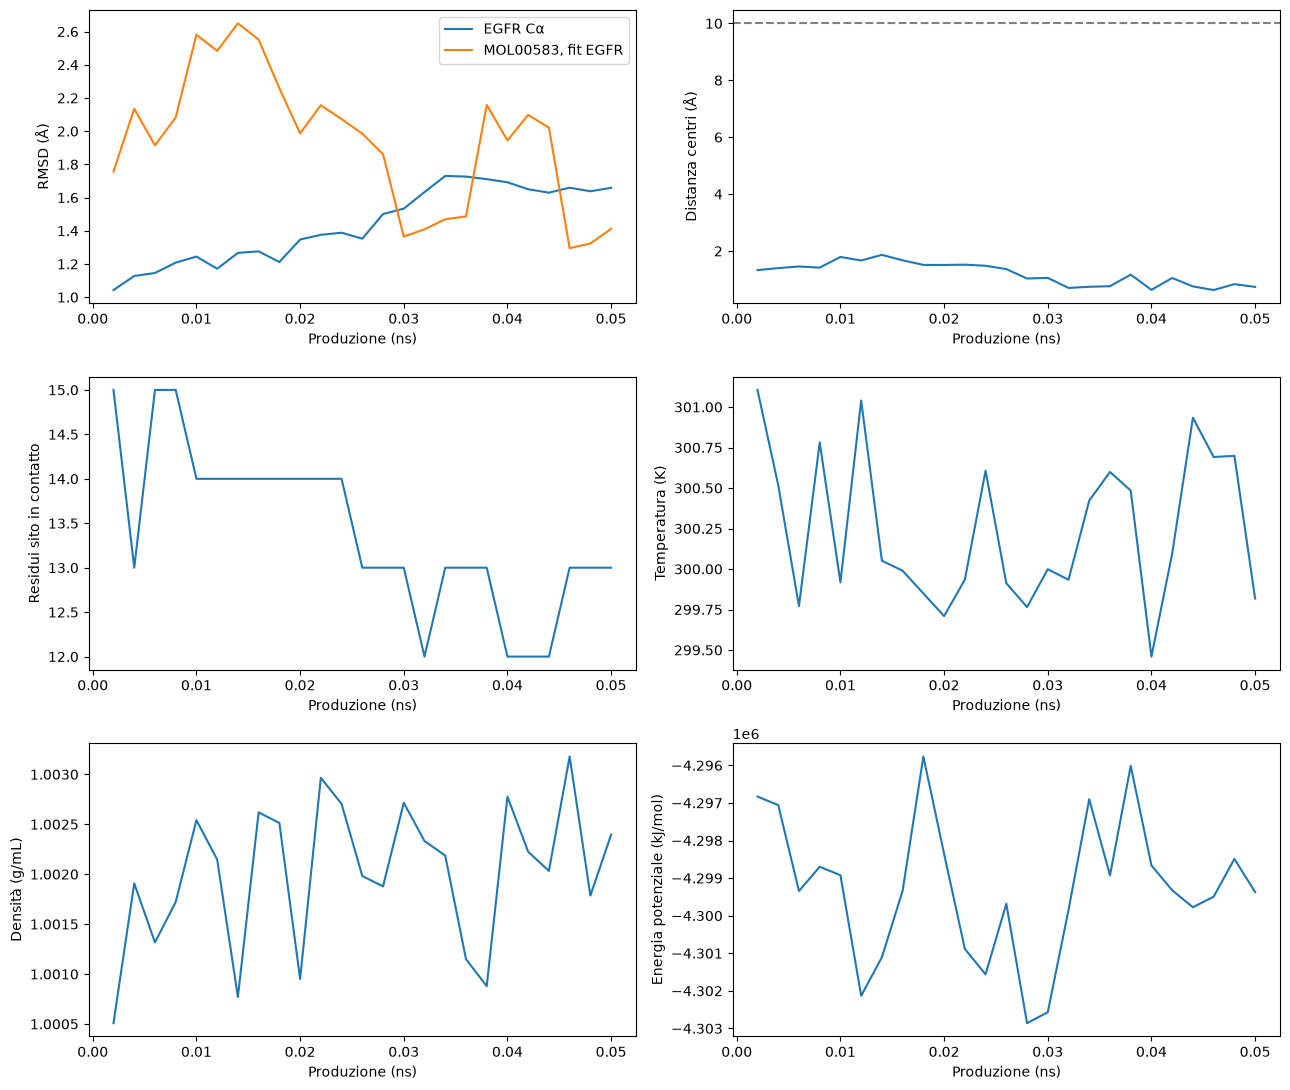

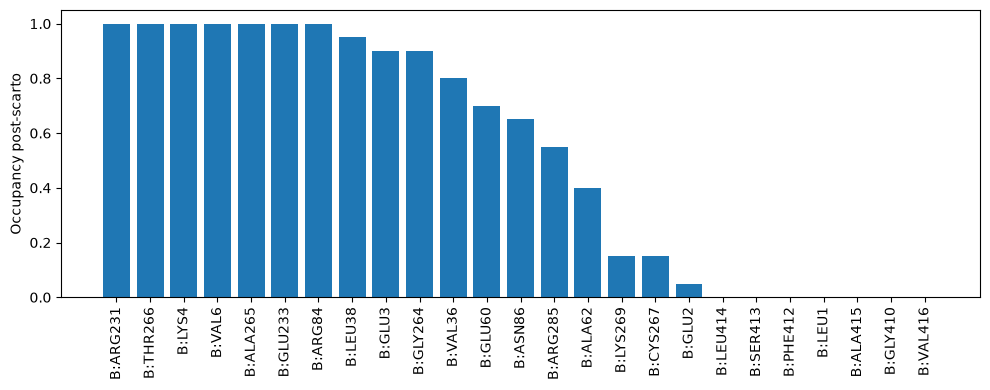

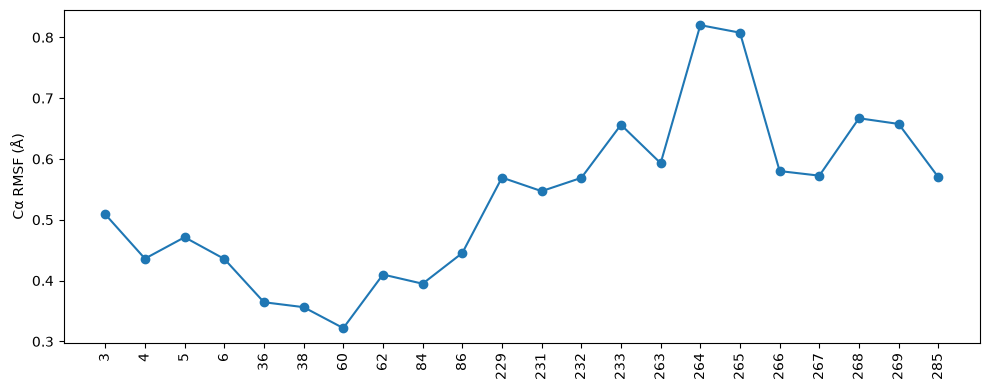

{
  "candidate": "MOL00583",
  "tier": "TIER_1_PRIMARY_COMPUTATIONAL_LEAD",
  "experimentally_validated": false,
  "mode": "smoke_test",
  "production_ps": 50.0,
  "analyzed_frames": 20,
  "discard_fraction": 0.2,
  "technical_qc_pass": true,
  "hydrogen_bonds": {
    "status": "computed",
    "n_triplets": 3,
    "method": "Baker-Hubbard geometric N/O"
  },
  "mean_ligand_RMSD_A": 1.8994073867797852,
  "retention_fraction_descriptive": 1.0,
  "persistent_residues": 14,
  "interpretation": "Dinamica descrittiva; nessuna validazione sperimentale o energia libera di binding."
}
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09h_mol00583_md/20260912T161426_861450Z_seed20260912


In [14]:
log = pd.read_csv(RUN/'tables/production.csv')
def col(keyword):
    return next(c for c in log if keyword.lower() in c.lower())
T = log[col('Temperature')].to_numpy(float)
rho = log[col('Density')].to_numpy(float)
E = log[col('Potential Energy')].to_numpy(float)
jump = float(np.linalg.norm(np.diff(aligned_all.xyz[:,ligheavy].mean(1),axis=0),axis=1).max())
qc = {
    'complete_frames': traj.n_frames==steps(PRODUCTION_PS)//interval,
    'finite_coordinates': bool(np.isfinite(traj.xyz).all()),
    'finite_thermodynamics': bool(np.isfinite(T).all() and np.isfinite(rho).all() and np.isfinite(E).all()),
    'mean_temperature_within_5K': bool(abs(T.mean()-TEMPERATURE_K)<=5),
    'mean_density_0.95_to_1.05_g_mL': bool(0.95<=rho.mean()<=1.05),
    'no_unwrapped_bond_over_3A': bool(bond_lengths.max()<0.30),
    'no_ligand_center_jump_over_1nm_per_saved_frame': jump<1.0,
    'production_restraints_absent': not any(isinstance(f,mm.CustomExternalForce) for f in system.getForces()),
}
pd.DataFrame([{'check':k,'pass':v} for k,v in qc.items()]).to_csv(RUN/'tables/09h_QC.csv',index=False)
fig,axs=plt.subplots(3,2,figsize=(13,11))
axs[0,0].plot(metrics.time_ps/1000,metrics.protein_CA_RMSD_A,label='EGFR Cα')
axs[0,0].plot(metrics.time_ps/1000,metrics.ligand_heavy_RMSD_receptor_fit_A,label='MOL00583, fit EGFR')
axs[0,0].set_ylabel('RMSD (Å)'); axs[0,0].legend()
axs[0,1].plot(metrics.time_ps/1000,metrics.ligand_site_center_distance_A)
axs[0,1].axhline(RETENTION_DISTANCE_NM*10,ls='--',color='gray'); axs[0,1].set_ylabel('Distanza centri (Å)')
axs[1,0].plot(metrics.time_ps/1000,metrics.site_contact_count); axs[1,0].set_ylabel('Residui sito in contatto')
axs[1,1].plot(log[col('Time')]/1000,T); axs[1,1].set_ylabel('Temperatura (K)')
axs[2,0].plot(log[col('Time')]/1000,rho); axs[2,0].set_ylabel('Densità (g/mL)')
axs[2,1].plot(log[col('Time')]/1000,E); axs[2,1].set_ylabel('Energia potenziale (kJ/mol)')
for ax in axs.flat: ax.set_xlabel('Produzione (ns)')
fig.tight_layout(); fig.savefig(RUN/'plots/md_overview.png',dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(10,4))
top_contacts=contacts.sort_values('occupancy',ascending=False).head(25)
ax.bar([f"{r.chain}:{r.residue_name}{r.residue_id}" for r in top_contacts.itertuples()],top_contacts.occupancy)
ax.set_ylabel('Occupancy post-scarto'); ax.tick_params(axis='x',rotation=90)
fig.tight_layout(); fig.savefig(RUN/'plots/contact_persistence.png',dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(rmsf_df.residue_id.astype(str),rmsf_df.RMSF_A,marker='o'); ax.set_ylabel('Cα RMSF (Å)')
ax.tick_params(axis='x',rotation=90); fig.tight_layout(); fig.savefig(RUN/'plots/site_rmsf.png',dpi=180); plt.show()
summary = dict(candidate=CANDIDATE,tier=TIER,experimentally_validated=False,
    mode='smoke_test' if FAST_TEST_MODE else 'production', production_ps=PRODUCTION_PS,
    analyzed_frames=analysis.n_frames,discard_fraction=DISCARD_FRACTION,
    technical_qc_pass=all(qc.values()),hydrogen_bonds=hb_status,
    mean_ligand_RMSD_A=float(summary_metrics.ligand_heavy_RMSD_receptor_fit_A.mean()),
    retention_fraction_descriptive=float(summary_metrics.retained_descriptive.mean()),
    persistent_residues=int(contacts.persistent.sum()),
    interpretation='Dinamica descrittiva; nessuna validazione sperimentale o energia libera di binding.')
dump(RUN/'09h_summary.json',summary)
# Snapshot periodici completi per 09i: stesso ordine del sistema XML, nessun allineamento.
full_top = mt.Topology.from_openmm(model.topology)
frame_indices = np.unique(np.linspace(int(traj.n_frames*DISCARD_FRACTION),traj.n_frames-1,
                                     min(20,analysis.n_frames),dtype=int))
for j in frame_indices:
    frame = mt.load_frame(str(RUN/'trajectories/production_full.dcd'),int(j),top=full_top)
    frame.save_pdb(str(RUN/f'structures/09i_snapshot_{j:06d}.pdb'))
dump(RUN/'09i_manifest.json', dict(
    candidate=CANDIDATE,tier=TIER,experimentally_validated=False,
    full_topology='structures/solvated.pdb',full_trajectory='trajectories/production_full.dcd',
    physical_system='states/physical_system.xml',production_system='states/production_system.xml',
    ligand_chemistry='inputs/ligand_openff.json',atom_map='tables/solute_atom_map.csv',
    solute_bonds='tables/solute_bonds.json',receptor_indices=rec_idx.tolist(),ligand_indices=lig_idx.tolist(),
    index_base=0,coordinate_units='nm internally; PDB Å',time_units='ps',
    frame_interval_ps=FRAME_PS,first_frame_time_ps=FRAME_PS,snapshot_frame_indices=frame_indices.tolist(),
    production_restraints=False,technical_qc_pass=all(qc.values()),
    note='09i deve verificare QC e convergenza; physical_system è PME esplicito, non un modello GBSA.'))
provenance.update(status='analysis_completed',summary=summary)
dump(RUN/'provenance.json',provenance)
# Hash di tutti gli artefatti, escluso il manifest stesso.
dump(RUN/'artifact_sha256.json',{str(p.relative_to(RUN)):sha256(p) for p in sorted(RUN.rglob('*')) if p.is_file()})
(RUN/'09h_report.md').write_text(
    '# 09h — MOL00583–EGFR\n\n'+json.dumps(summary,indent=2,ensure_ascii=False)+
    '\n\nTIER_1_PRIMARY_COMPUTATIONAL_LEAD, selezionata in 09g. Lead computazionale non validato sperimentalmente.\n'
    'Lo stato near-miss/rescue è preservato. QC tecnico e ritenzione sono evidenze distinte.\n',encoding='utf-8')
print(json.dumps(summary,indent=2)); print('Output:',RUN)

## 12. Ripartenza, limiti e riferimenti
Per una nuova replica: riavviare il kernel, cambiare `SEED` e rieseguire. Per una continuazione esatta usare `production_system.xml`, `production_integrator.xml`, la topologia completa e `production_latest.chk` nello **stesso ambiente/piattaforma**. Non rilanciare la cella produzione su file esistenti: un resume richiede nuovi segmenti DCD/log con step iniziale registrato e deduplicazione esplicita. Questo notebook non concatena automaticamente segmenti interrotti. Lo stato XML è portabile più del checkpoint, ma non preserva tutta la sequenza stocastica.

I parametri della proteina/acqua e le durate di riferimento sono stati verificati nei notebook locali 07a/07d. L'aggiunta di OpenFF per MOL00583 è specifica di 09h. La prima esecuzione deve verificare anche termini, disolfuri, eventuali loop/glicani mancanti e microstato del ligando. La parametrizzazione non prova la correttezza biologica del modello.

Riferimenti software consultati per l'implementazione:
- [OpenMM — Running simulations](https://docs.openmm.org/latest/userguide/application/02_running_sims.html)
- [OpenMMForceFields — template OpenFF e cariche](https://github.com/openmm/openmmforcefields)
- [OpenFF Toolkit](https://github.com/openforcefield/openff-toolkit)
- [MDTraj — Baker–Hubbard e soglie geometriche](https://mdtraj.org/1.9.4/api/generated/mdtraj.baker_hubbard.html)